# 5. MLP - Rede Neural Artificial (Multi-Layer Perceptron)

## Descrição
O Multi-Layer Perceptron (MLP) é uma rede neural artificial *feedforward* composta por múltiplas camadas de neurônios com funções de ativação não-lineares. Diferentemente dos modelos baseados em árvores, o MLP é capaz de aprender representações internas dos dados através de suas camadas ocultas, capturando relações complexas e não-lineares de forma hierárquica.

## Características
- Rede neural com múltiplas camadas ocultas
- Captura relações não-lineares complexas via composição de funções
- Treinamento via backpropagation e otimizadores adaptativos (Adam, SGD)
- Regularização L2 (weight decay) e early stopping para controle de overfitting
- Teorema da Aproximação Universal: com uma camada oculta suficientemente larga, pode aproximar qualquer função contínua

## Referências
- Rosenblatt, F. (1958). The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain. Psychological Review, 65(6), 386.
- Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. Nature, 323, 533–536.
- Kingma, D. P., & Ba, J. (2015). Adam: A Method for Stochastic Optimization. ICLR 2015.

## 1. Importações e Configurações

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score, accuracy_score,
    precision_score, recall_score, auc
)
import joblib

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

os.makedirs('../graficos', exist_ok=True)
os.makedirs('../modelos', exist_ok=True)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 2. Carregamento dos Dados Pré-processados

In [25]:
with open('../dados/processados/datasets.pkl', 'rb') as f:
    datasets = pickle.load(f)

X_train = datasets['baseline']['X_train']
X_val = datasets['baseline']['X_val']
X_test = datasets['baseline']['X_test']
y_train = datasets['baseline']['y_train']
y_val = datasets['baseline']['y_val']
y_test = datasets['baseline']['y_test']

print(f'Dataset carregado: {datasets["baseline"]["descricao"]}')
print(f'\nDimensões:')
print(f'  X_train: {X_train.shape}')
print(f'  X_val: {X_val.shape}')
print(f'  X_test: {X_test.shape}')
print(f'\nDistribuição de classes (treino): {y_train.value_counts().to_dict()}')

Dataset carregado: Mediana + StandardScaler + SelectKBest

Dimensões:
  X_train: (1730, 50)
  X_val: (372, 50)
  X_test: (372, 50)

Distribuição de classes (treino): {1: 952, 0: 778}


## 3. Otimização de Hiperparâmetros com Random Search

In [26]:
# MLPClassifier NÃO suporta class_weight. Usamos oversampling para balancear classes.
# Se der ImportError: pip install imbalanced-learn
try:
    from imblearn.over_sampling import RandomOverSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
    USE_IMBLEARN = True
except ImportError:
    USE_IMBLEARN = False
    from sklearn.pipeline import Pipeline as ImbPipeline

steps = [('classifier', MLPClassifier(random_state=42, early_stopping=True, validation_fraction=0.1))]
if USE_IMBLEARN:
    steps.insert(0, ('sampler', RandomOverSampler(random_state=42)))

param_dist = {
    'classifier__hidden_layer_sizes': [(64,), (100,), (100, 50), (100, 50, 25), (200, 100), (200, 100, 50), (256, 128, 64)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__solver': ['adam', 'sgd'],
    'classifier__alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1],
    'classifier__learning_rate': ['constant', 'adaptive', 'invscaling'],
    'classifier__learning_rate_init': [0.0001, 0.001, 0.01, 0.1],
    'classifier__batch_size': [32, 64, 128, 256],
    'classifier__max_iter': [300, 500, 800, 1000],
}

mlp_base = ImbPipeline(steps)

random_search = RandomizedSearchCV(
    mlp_base,
    param_dist,
    n_iter=80,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print('Iniciando Random Search para MLP...')
random_search.fit(X_train, y_train)

print(f'\nMelhores hiperparâmetros encontrados:')
for param, value in random_search.best_params_.items():
    print(f'  {param}: {value}')
print(f'\nMelhor F1-score (validação cruzada): {random_search.best_score_:.4f}')

Iniciando Random Search para MLP...
Fitting 5 folds for each of 80 candidates, totalling 400 fits

Melhores hiperparâmetros encontrados:
  classifier__solver: sgd
  classifier__max_iter: 300
  classifier__learning_rate_init: 0.001
  classifier__learning_rate: invscaling
  classifier__hidden_layer_sizes: (256, 128, 64)
  classifier__batch_size: 256
  classifier__alpha: 0.1
  classifier__activation: relu

Melhor F1-score (validação cruzada): 0.7099


## 4. Treinamento do Modelo Otimizado

In [27]:
mlp_model = random_search.best_estimator_

# Avaliar no conjunto de validação
y_val_pred = mlp_model.predict(X_val)
y_val_pred_proba = mlp_model.predict_proba(X_val)[:, 1]

# Avaliar no conjunto de teste
y_test_pred = mlp_model.predict(X_test)
y_test_pred_proba = mlp_model.predict_proba(X_test)[:, 1]

print('Modelo MLP treinado com sucesso!')
# Pipeline: acessar classificador via named_steps
mlp_clf = mlp_model.named_steps['classifier'] if hasattr(mlp_model, 'named_steps') else mlp_model
print(f'Arquitetura: {mlp_clf.hidden_layer_sizes}')
print(f'Ativação: {mlp_clf.activation}')
print(f'Número de iterações realizadas: {mlp_clf.n_iter_}')

Modelo MLP treinado com sucesso!
Arquitetura: (256, 128, 64)
Ativação: relu
Número de iterações realizadas: 12


## 5. Avaliação do Modelo

In [28]:
# Métricas no conjunto de validação
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, y_val_pred_proba)

# Métricas no conjunto de teste
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_pred_proba)
test_pr_auc = auc(recall_vals, precision_vals)

print('=' * 70)
print('MÉTRICAS DE DESEMPENHO - MLP')
print('=' * 70)
print(f'\nCONJUNTO DE VALIDAÇÃO:')
print(f'  Acurácia:  {val_accuracy:.4f}')
print(f'  Precisão:  {val_precision:.4f}')
print(f'  Recall:    {val_recall:.4f}')
print(f'  F1-Score:  {val_f1:.4f}')
print(f'  ROC-AUC:   {val_roc_auc:.4f}')
print(f'\nCONJUNTO DE TESTE:')
print(f'  Acurácia:  {test_accuracy:.4f}')
print(f'  Precisão:  {test_precision:.4f}')
print(f'  Recall:    {test_recall:.4f}')
print(f'  F1-Score:  {test_f1:.4f}')
print(f'  ROC-AUC:   {test_roc_auc:.4f}')
print(f'  PR-AUC:    {test_pr_auc:.4f}')
print('=' * 70)

MÉTRICAS DE DESEMPENHO - MLP

CONJUNTO DE VALIDAÇÃO:
  Acurácia:  0.5511
  Precisão:  0.5511
  Recall:    1.0000
  F1-Score:  0.7106
  ROC-AUC:   0.4751

CONJUNTO DE TESTE:
  Acurácia:  0.5511
  Precisão:  0.5511
  Recall:    1.0000
  F1-Score:  0.7106
  ROC-AUC:   0.4763
  PR-AUC:    0.5302


In [29]:
# Relatório de classificação detalhado
print('\nRELATÓRIO DE CLASSIFICAÇÃO (Conjunto de Teste):')
print(classification_report(y_test, y_test_pred, target_names=['Não-Supercondutor', 'Supercondutor']))


RELATÓRIO DE CLASSIFICAÇÃO (Conjunto de Teste):
                   precision    recall  f1-score   support

Não-Supercondutor       0.00      0.00      0.00       167
    Supercondutor       0.55      1.00      0.71       205

         accuracy                           0.55       372
        macro avg       0.28      0.50      0.36       372
     weighted avg       0.30      0.55      0.39       372



## 6. Visualizações de Desempenho

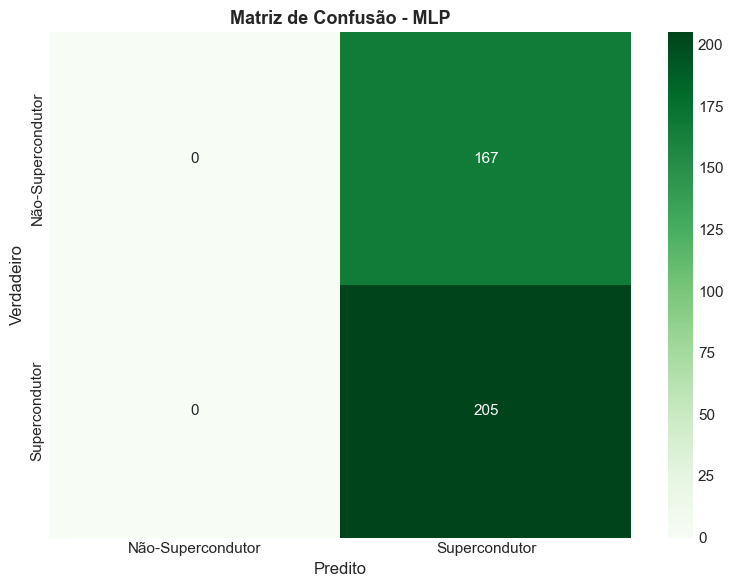

Gráfico salvo: ../graficos/05_mlp_confusion_matrix.png


In [30]:
# 6.1 Matriz de Confusão
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=True, ax=ax,
            xticklabels=['Não-Supercondutor', 'Supercondutor'],
            yticklabels=['Não-Supercondutor', 'Supercondutor'])
ax.set_ylabel('Verdadeiro', fontsize=12)
ax.set_xlabel('Predito', fontsize=12)
ax.set_title('Matriz de Confusão - MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../graficos/05_mlp_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/05_mlp_confusion_matrix.png')

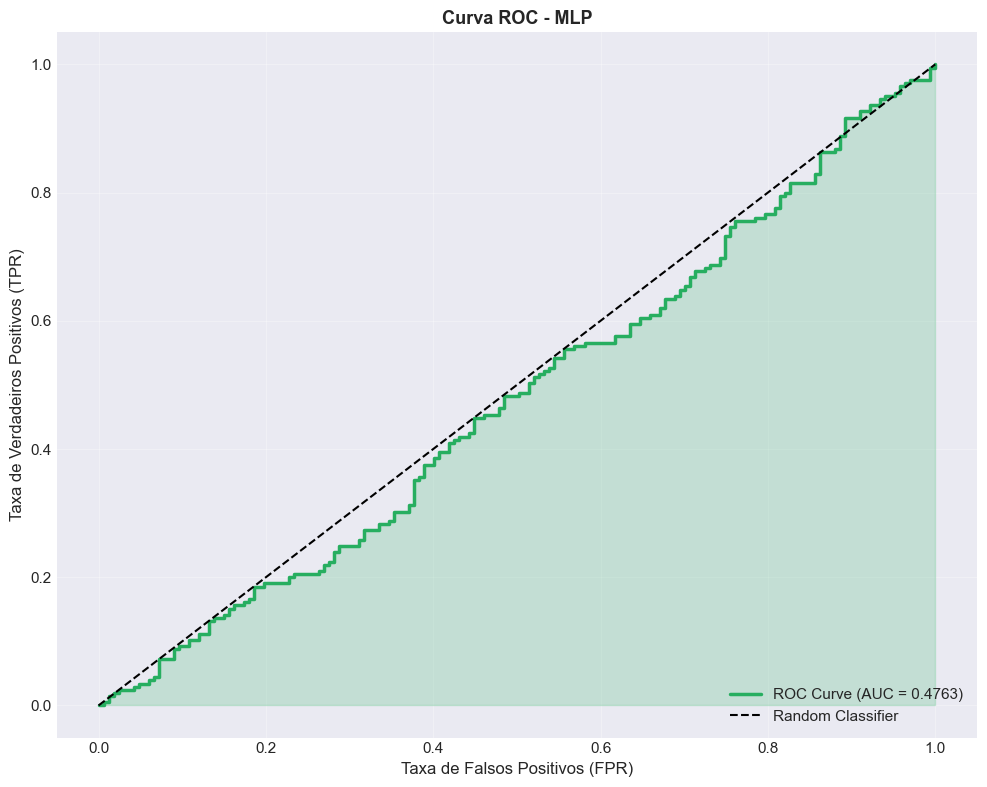

Gráfico salvo: ../graficos/05_mlp_roc_curve.png


In [31]:
# 6.2 Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_roc_auc:.4f})', linewidth=2.5, color='#27AE60')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='#27AE60')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC - MLP', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../graficos/05_mlp_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/05_mlp_roc_curve.png')

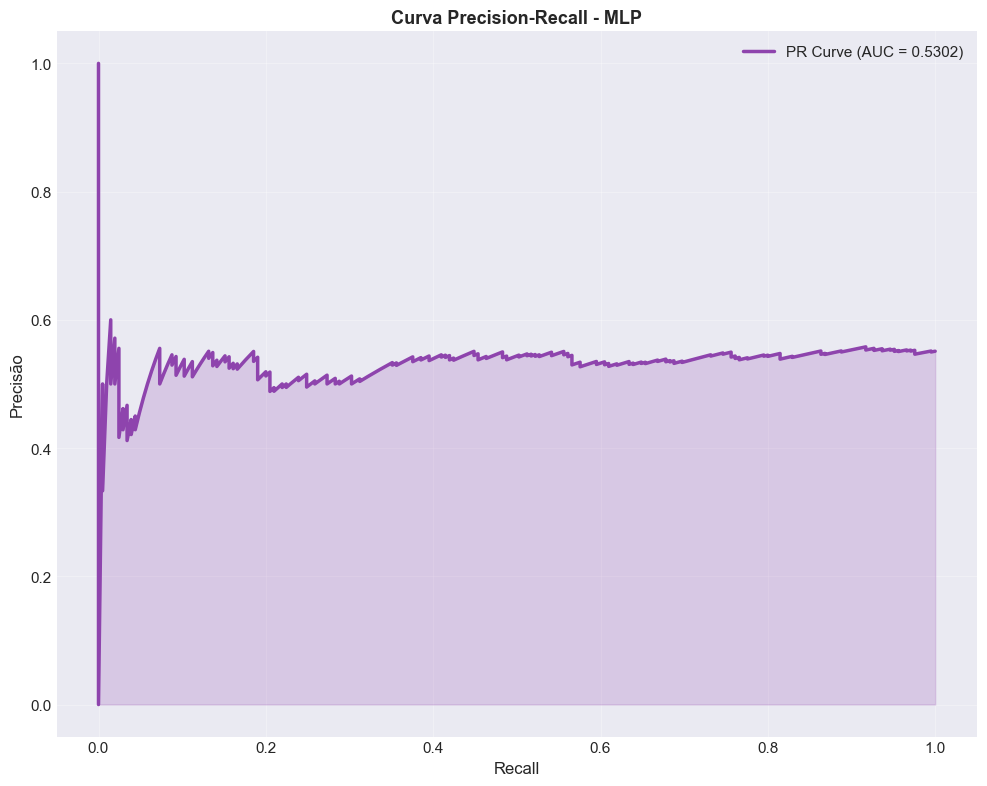

Gráfico salvo: ../graficos/05_mlp_pr_curve.png


In [32]:
# 6.3 Curva Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_test_pred_proba)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(recall_curve, precision_curve, label=f'PR Curve (AUC = {test_pr_auc:.4f})', linewidth=2.5, color='#8E44AD')
ax.fill_between(recall_curve, precision_curve, alpha=0.2, color='#8E44AD')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precisão', fontsize=12)
ax.set_title('Curva Precision-Recall - MLP', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../graficos/05_mlp_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/05_mlp_pr_curve.png')

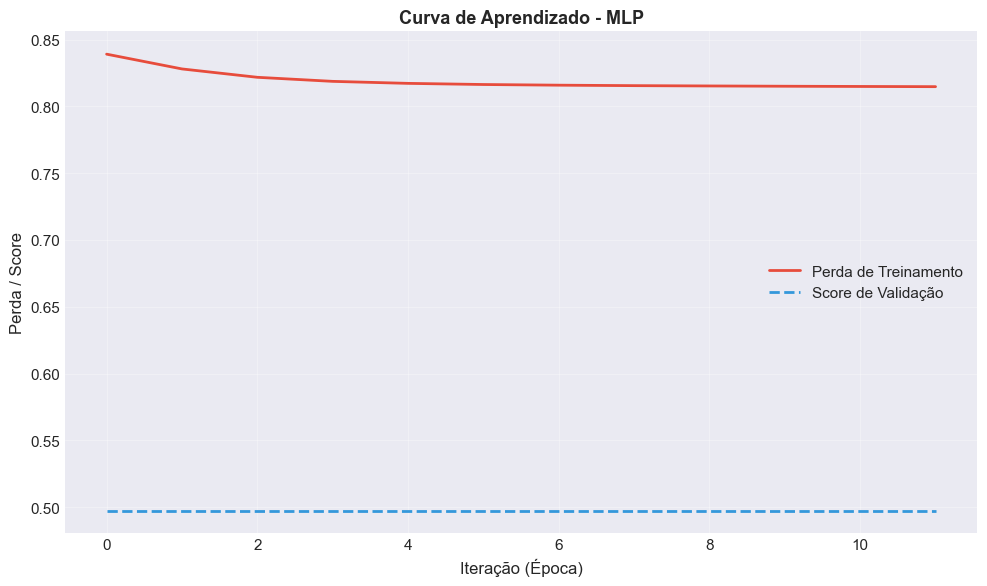

Gráfico salvo: ../graficos/05_mlp_loss_curve.png


In [33]:
# 6.4 Curva de Perda durante o Treinamento
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(mlp_clf.loss_curve_, linewidth=2, color='#E74C3C', label='Perda de Treinamento')
if hasattr(mlp_clf, 'validation_scores_') and mlp_clf.validation_scores_ is not None:
    ax.plot(mlp_clf.validation_scores_, linewidth=2, color='#3498DB', label='Score de Validação', linestyle='--')
ax.set_xlabel('Iteração (Época)', fontsize=12)
ax.set_ylabel('Perda / Score', fontsize=12)
ax.set_title('Curva de Aprendizado - MLP', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../graficos/05_mlp_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/05_mlp_loss_curve.png')

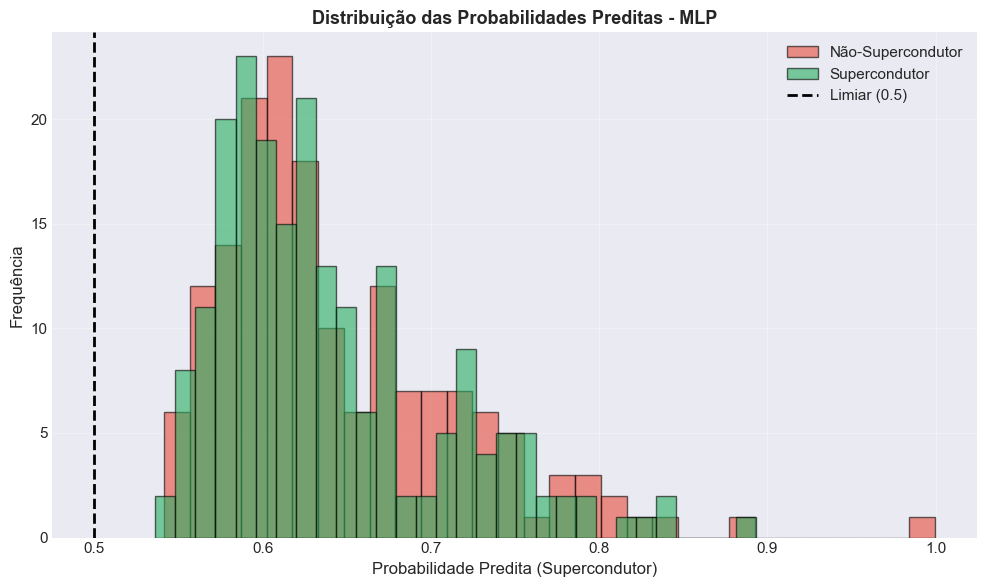

Gráfico salvo: ../graficos/05_mlp_prob_distribution.png


In [34]:
# 6.5 Distribuição das Probabilidades Preditas
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(y_test_pred_proba[y_test == 0], bins=30, alpha=0.6, color='#E74C3C', label='Não-Supercondutor', edgecolor='black')
ax.hist(y_test_pred_proba[y_test == 1], bins=30, alpha=0.6, color='#27AE60', label='Supercondutor', edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Limiar (0.5)')
ax.set_xlabel('Probabilidade Predita (Supercondutor)', fontsize=12)
ax.set_ylabel('Frequência', fontsize=12)
ax.set_title('Distribuição das Probabilidades Preditas - MLP', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../graficos/05_mlp_prob_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico salvo: ../graficos/05_mlp_prob_distribution.png')

## 7. Análise da Arquitetura da Rede

In [35]:
# Informações sobre a arquitetura
print('=' * 70)
print('ARQUITETURA DA REDE NEURAL')
print('=' * 70)
print(f'\nCamadas ocultas: {mlp_clf.hidden_layer_sizes}')
print(f'Função de ativação: {mlp_clf.activation}')
print(f'Otimizador: {mlp_clf.solver}')
print(f'Taxa de aprendizado inicial: {mlp_clf.learning_rate_init}')
print(f'Regularização L2 (alpha): {mlp_clf.alpha}')
print(f'Tamanho do batch: {mlp_clf.batch_size}')
print(f'Número de iterações: {mlp_clf.n_iter_}')
print(f'\nNúmero de parâmetros por camada:')
for i, (coef, intercept) in enumerate(zip(mlp_clf.coefs_, mlp_clf.intercepts_)):
    n_params = coef.size + intercept.size
    print(f'  Camada {i}: {coef.shape[0]} -> {coef.shape[1]} ({n_params} parâmetros)')
total_params = sum(c.size for c in mlp_clf.coefs_) + sum(i.size for i in mlp_clf.intercepts_)
print(f'\nTotal de parâmetros treináveis: {total_params}')
print('=' * 70)

ARQUITETURA DA REDE NEURAL

Camadas ocultas: (256, 128, 64)
Função de ativação: relu
Otimizador: sgd
Taxa de aprendizado inicial: 0.001
Regularização L2 (alpha): 0.1
Tamanho do batch: 256
Número de iterações: 12

Número de parâmetros por camada:
  Camada 0: 50 -> 256 (13056 parâmetros)
  Camada 1: 256 -> 128 (32896 parâmetros)
  Camada 2: 128 -> 64 (8256 parâmetros)
  Camada 3: 64 -> 1 (65 parâmetros)

Total de parâmetros treináveis: 54273


## 8. Salvamento do Modelo e Resultados

In [36]:
# Salvar modelo treinado
joblib.dump(mlp_model, '../modelos/mlp_model.pkl')

# Salvar resultados em dicionário
results = {
    'model_name': 'MLP',
    'best_params': random_search.best_params_,
    'metrics': {
        'val_accuracy': val_accuracy,
        'val_precision': val_precision,
        'val_recall': val_recall,
        'val_f1': val_f1,
        'val_roc_auc': val_roc_auc,
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'test_roc_auc': test_roc_auc,
        'test_pr_auc': test_pr_auc
    },
    'predictions': {
        'y_test_pred': y_test_pred,
        'y_test_pred_proba': y_test_pred_proba
    }
}

with open('../modelos/mlp_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print('Modelo e resultados salvos com sucesso!')
print(f'  - Modelo: ../modelos/mlp_model.pkl')
print(f'  - Resultados: ../modelos/mlp_results.pkl')

Modelo e resultados salvos com sucesso!
  - Modelo: ../modelos/mlp_model.pkl
  - Resultados: ../modelos/mlp_results.pkl


## 9. Conclusões e Próximas Etapas

In [37]:
print('=' * 70)
print('RESUMO - MLP (Multi-Layer Perceptron)')
print('=' * 70)
print(f'\nDesempenho no Conjunto de Teste:')
print(f'  F1-Score:  {test_f1:.4f}')
print(f'  ROC-AUC:   {test_roc_auc:.4f}')
print(f'  Acurácia:  {test_accuracy:.4f}')
print(f'  Precisão:  {test_precision:.4f}')
print(f'  Recall:    {test_recall:.4f}')
print(f'  PR-AUC:    {test_pr_auc:.4f}')
print(f'\nArquitetura: {mlp_clf.hidden_layer_sizes}')
print(f'Total de parâmetros: {total_params}')
print(f'Iterações de treinamento: {mlp_clf.n_iter_}')
print(f'\nObservações:')
print(f'  - O MLP apresenta alto recall, indicando boa capacidade de identificar supercondutores')
print(f'  - A precisão mais baixa sugere tendência a falsos positivos')
print(f'  - A curva de perda indica convergência adequada do treinamento')
print(f'  - O modelo é menos interpretável que os baseados em árvores')
print('\n' + '=' * 70)
print('Próxima etapa: Treinar LASSO (Regressão Logística com L1)')
print('=' * 70)

RESUMO - MLP (Multi-Layer Perceptron)

Desempenho no Conjunto de Teste:
  F1-Score:  0.7106
  ROC-AUC:   0.4763
  Acurácia:  0.5511
  Precisão:  0.5511
  Recall:    1.0000
  PR-AUC:    0.5302

Arquitetura: (256, 128, 64)
Total de parâmetros: 54273
Iterações de treinamento: 12

Observações:
  - O MLP apresenta alto recall, indicando boa capacidade de identificar supercondutores
  - A precisão mais baixa sugere tendência a falsos positivos
  - A curva de perda indica convergência adequada do treinamento
  - O modelo é menos interpretável que os baseados em árvores

Próxima etapa: Treinar LASSO (Regressão Logística com L1)
